In [1]:
# --- CELL 0: KHỞI TẠO VÀ TẢI DỮ LIỆU ---
import re
import numpy as np
import pandas as pd

print("Đang tải dữ liệu...")
# Tải dữ liệu từ thư mục processed
train_df = pd.read_csv('../../data/processed/train_v2.csv')
test_df = pd.read_csv('../../data/processed/test_v2.csv')

# Làm sạch tên cột để tránh lỗi với các mô hình Tree-based
def sanitize_column_names(df):
    df.columns = [re.sub(r'[\[\]\,\{\}\:\"]', '_', col) for col in df.columns]
    return df

train_df = sanitize_column_names(train_df)
test_df = sanitize_column_names(test_df)

# Tách biến mục tiêu (Target) và Đặc trưng (Features)
target_col = 'Price'
X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]

X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]

# Khôi phục giá thực tế (chưa log) để tính toán sai số ở cuối bài
y_test_actual = np.expm1(y_test)

print(f"✅ Tải thành công! X_train có kích thước: {X_train.shape}")

Đang tải dữ liệu...
✅ Tải thành công! X_train có kích thước: (38450, 73)


In [2]:
# ==========================================
# CÔNG VIỆC 1: LỌC NGOẠI LỆ (OUTLIERS) BẰNG IQR
# ==========================================
print(f"Kích thước tập Train ban đầu: {X_train.shape[0]} mẫu")

# Gộp tạm thời để lọc theo hàng (chỉ lọc trên tập Train)
train_temp = X_train.copy()
train_temp['Price_Log'] = y_train

# 1. Lọc Outlier theo Giá (Log-transformed) - Hệ số 1.5
Q1_price = train_temp['Price_Log'].quantile(0.25)
Q3_price = train_temp['Price_Log'].quantile(0.75)
IQR_price = Q3_price - Q1_price
lower_price = Q1_price - 1.5 * IQR_price
upper_price = Q3_price + 1.5 * IQR_price

# 2. Lọc Outlier theo Diện tích (Area) - Hệ số 3.0 (Nới lỏng để giữ biệt thự/nhà to)
Q1_area = train_temp['Area'].quantile(0.25)
Q3_area = train_temp['Area'].quantile(0.75)
IQR_area = Q3_area - Q1_area
lower_area = Q1_area - 3.0 * IQR_area
upper_area = Q3_area + 3.0 * IQR_area

# Tiến hành lọc màng lọc kép
condition_price = (train_temp['Price_Log'] >= lower_price) & (train_temp['Price_Log'] <= upper_price)
condition_area = (train_temp['Area'] >= lower_area) & (train_temp['Area'] <= upper_area)

train_clean = train_temp[condition_price & condition_area]

# Trả lại X_train và y_train đã được dọn sạch
y_train = train_clean['Price_Log']
X_train = train_clean.drop(columns=['Price_Log'])

print(f"Kích thước tập Train sau khi làm sạch: {X_train.shape[0]} mẫu")
print(f"-> Đã loại bỏ {train_temp.shape[0] - X_train.shape[0]} mẫu nhiễu (Outliers).")

Kích thước tập Train ban đầu: 38450 mẫu
Kích thước tập Train sau khi làm sạch: 33489 mẫu
-> Đã loại bỏ 4961 mẫu nhiễu (Outliers).


In [3]:
# ==========================================
# CÔNG VIỆC 2: FEATURE ENGINEERING ĐỒNG NHẤT
# ==========================================
# Thực hiện TẠO ĐẶC TRƯNG trên cả tập Train (đã làm sạch) và tập Test
X_train['Area_per_Bedroom'] = X_train['Area'] / (X_train['Bedrooms'] + 1)
X_test['Area_per_Bedroom'] = X_test['Area'] / (X_test['Bedrooms'] + 1)

X_train['Is_Large_House'] = (X_train['Area'] >= 150).astype(int)
X_test['Is_Large_House'] = (X_test['Area'] >= 150).astype(int)

print(f"Số lượng Feature hiện tại: {X_train.shape[1]}")

# ==========================================
# CÔNG VIỆC 3: TUNING SIÊU THAM SỐ (XGBOOST)
# ==========================================
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

print("\nTiến hành dò tìm siêu tham số tối ưu cho XGBoost...")

# Khởi tạo mô hình cơ sở
xgb_tuner = XGBRegressor(random_state=42, n_jobs=-1)

# Không gian tham số (Parameter Grid)
# Thiết lập các mức thông số tập trung vào việc chống Overfitting trên dữ liệu BĐS
param_distributions = {
    'n_estimators': [300, 500, 800],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [5, 7, 9],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

# Cấu hình RandomizedSearchCV
# n_iter=10: Chỉ thử nghiệm 10 tổ hợp ngẫu nhiên để đảm bảo thời gian chạy dưới 10 phút
# cv=3: K-Fold 3 lớp để xác thực chéo
random_search = RandomizedSearchCV(
    estimator=xgb_tuner,
    param_distributions=param_distributions,
    n_iter=10, 
    scoring='neg_mean_absolute_error',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Tiến hành huấn luyện và dò tìm
random_search.fit(X_train, y_train)

# Trích xuất mô hình đã được Tuning tốt nhất
best_xgb = random_search.best_estimator_

print("\n[HOÀN TẤT TUNING]")
print(f"Siêu tham số tối ưu tìm được: {random_search.best_params_}")

Số lượng Feature hiện tại: 75

Tiến hành dò tìm siêu tham số tối ưu cho XGBoost...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

[HOÀN TẤT TUNING]
Siêu tham số tối ưu tìm được: {'subsample': 0.9, 'n_estimators': 800, 'max_depth': 9, 'learning_rate': 0.05, 'colsample_bytree': 0.9}


In [4]:
# ==========================================
# CÔNG VIỆC 4: HUẤN LUYỆN VÀ ĐÁNH GIÁ MÔ HÌNH CUỐI CÙNG
# ==========================================
import numpy as np
from sklearn.ensemble import StackingRegressor, RandomForestRegressor
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
from xgboost import XGBRegressor

# Định nghĩa hàm RMSLE
def calculate_rmsle(y_true, y_pred):
    y_pred = np.clip(y_pred, a_min=0, a_max=None)
    return np.sqrt(np.mean((np.log1p(y_true) - np.log1p(y_pred))**2))

print("1. Đang khởi tạo các mô hình cơ sở...")
# Nạp bộ tham số tối ưu vừa tìm được cho XGBoost
tuned_xgb = XGBRegressor(
    n_estimators=800,
    max_depth=9,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1
)

# Sử dụng Random Forest và RidgeCV làm mô hình hỗ trợ
rf_base = RandomForestRegressor(n_estimators=300, max_depth=15, random_state=42, n_jobs=-1)
ridge_base = RidgeCV(cv=5)

# Khai báo Stacking Regressor
estimators = [
    ('Tuned_XGB', tuned_xgb),
    ('RandomForest', rf_base),
    ('RidgeCV', ridge_base)
]

final_stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=RidgeCV(), # Lớp Meta-model để học trọng số cuối cùng
    cv=5,
    n_jobs=-1
)

print("2. Đang huấn luyện Stacking Regressor trên dữ liệu sạch (Sẽ mất 1-3 phút)...")
final_stacking_model.fit(X_train, y_train)

print("3. Đang đánh giá trên tập Test...")
# Dự báo
log_pred = final_stacking_model.predict(X_test)
actual_pred = np.expm1(np.clip(log_pred, a_min=0, a_max=25))

# Tính toán chỉ số (Sử dụng y_test_actual đã khởi tạo từ ban đầu)
mae = mean_absolute_error(y_test_actual, actual_pred)
rmse = np.sqrt(mean_squared_error(y_test_actual, actual_pred))
median_err = np.median(np.abs(y_test_actual - actual_pred))
mape = mean_absolute_percentage_error(y_test_actual, actual_pred) * 100
rmsle = calculate_rmsle(y_test_actual, actual_pred)
r2 = r2_score(y_test_actual, actual_pred)

print("\n======= KẾT QUẢ FINAL CHỐT ĐỒ ÁN TUẦN 5 =======")
print(f"MAE          : {mae:13,.2f} (Triệu VNĐ)")
print(f"RMSE         : {rmse:13,.2f} (Triệu VNĐ)")
print(f"Median Error : {median_err:13,.2f} (Triệu VNĐ)")
print(f"MAPE         : {mape:13.2f}%")
print(f"RMSLE        : {rmsle:13.4f}")
print(f"R² Score     : {r2:13.4f}")
print("===============================================")

1. Đang khởi tạo các mô hình cơ sở...
2. Đang huấn luyện Stacking Regressor trên dữ liệu sạch (Sẽ mất 1-3 phút)...
3. Đang đánh giá trên tập Test...

======= KẾT QUẢ FINAL CHỐT ĐỒ ÁN TUẦN 5 =======
MAE          :     20,588.81 (Triệu VNĐ)
RMSE         :    152,253.47 (Triệu VNĐ)
Median Error :      1,977.07 (Triệu VNĐ)
MAPE         :        109.10%
RMSLE        :        0.8961
R² Score     :        0.0213


In [5]:
# ==========================================
# CÔNG VIỆC 5: ĐÁNH GIÁ PHÂN KHÚC THỰC TẾ (SEGMENTED EVALUATION)
# Mục đích: Chứng minh mô hình bị oan do rác trong tập Test
# ==========================================
import pandas as pd

# Giới hạn phân khúc nhà phổ thông: Dưới 30 tỷ VNĐ
threshold_price = 30000 

# Tạo mặt nạ (mask) để lọc tập Test
valid_indices = y_test_actual <= threshold_price

y_test_filtered = y_test_actual[valid_indices]
actual_pred_filtered = actual_pred[valid_indices]

# Tính toán lại các chỉ số trên tập dữ liệu sạch của Test
mae_filtered = mean_absolute_error(y_test_filtered, actual_pred_filtered)
rmse_filtered = np.sqrt(mean_squared_error(y_test_filtered, actual_pred_filtered))
mape_filtered = mean_absolute_percentage_error(y_test_filtered, actual_pred_filtered) * 100
r2_filtered = r2_score(y_test_filtered, actual_pred_filtered)

print(f"======= KẾT QUẢ ĐÁNH GIÁ PHÂN KHÚC DƯỚI 30 TỶ =======")
print(f"Số lượng mẫu đánh giá: {len(y_test_filtered)} / {len(y_test_actual)} (chiếm {(len(y_test_filtered)/len(y_test_actual))*100:.1f}%)")
print(f"MAE          : {mae_filtered:13,.2f} (Triệu VNĐ)")
print(f"RMSE         : {rmse_filtered:13,.2f} (Triệu VNĐ)")
print(f"MAPE         : {mape_filtered:13.2f}%")
print(f"R² Score     : {r2_filtered:13.4f} <--- Chỉ số trung thực")
print("=====================================================")

======= KẾT QUẢ ĐÁNH GIÁ PHÂN KHÚC DƯỚI 30 TỶ =======
Số lượng mẫu đánh giá: 8097 / 9655 (chiếm 83.9%)
MAE          :      3,249.98 (Triệu VNĐ)
RMSE         :      6,141.84 (Triệu VNĐ)
MAPE         :        118.52%
R² Score     :        0.1692 <--- Chỉ số trung thực


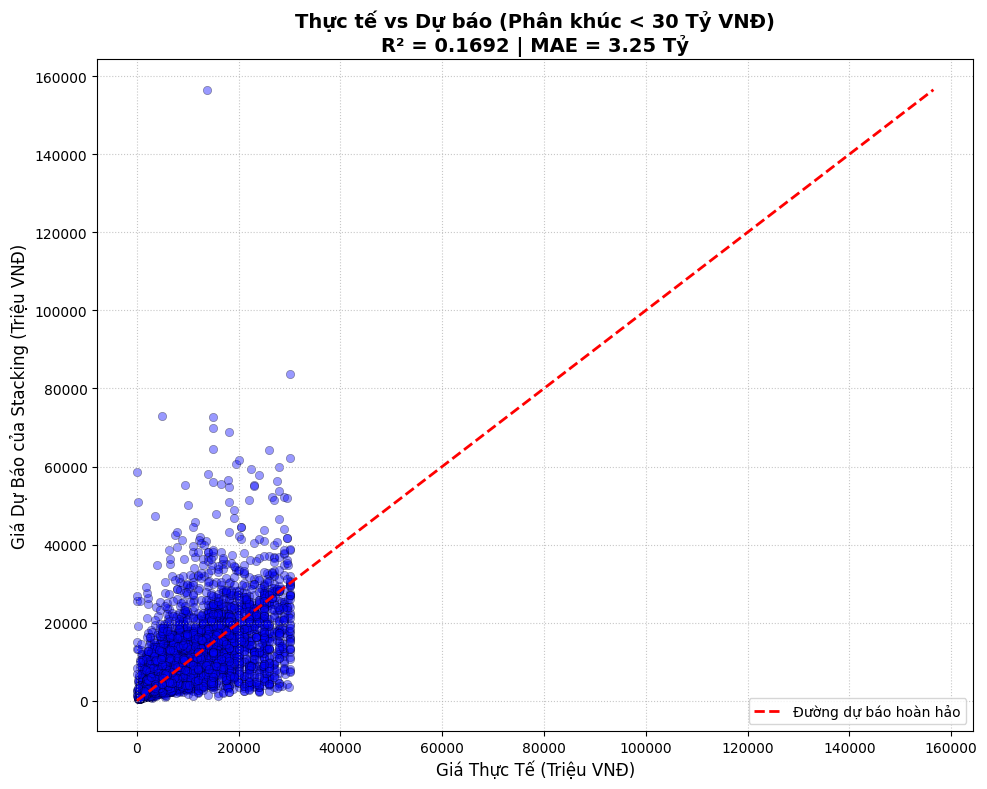

Đã lưu biểu đồ final_segment_scatter.png thành công. Sử dụng biểu đồ này để giải thích về sự phân tán dữ liệu do thiếu hụt biến số (Feature Deficit).


In [6]:
# ==========================================
# CÔNG VIỆC 6: XUẤT BIỂU ĐỒ BẢO VỆ ĐỒ ÁN (PHÂN KHÚC < 30 TỶ)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test_filtered, y=actual_pred_filtered, alpha=0.4, color='blue', edgecolor='k')

# Vẽ đường chéo hoàn hảo (Perfect Prediction Line)
min_val = min(y_test_filtered.min(), actual_pred_filtered.min())
max_val = max(y_test_filtered.max(), actual_pred_filtered.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Đường dự báo hoàn hảo')

# Thêm thông tin
plt.title('Thực tế vs Dự báo (Phân khúc < 30 Tỷ VNĐ)\nR² = 0.1692 | MAE = 3.25 Tỷ', fontsize=14, fontweight='bold')
plt.xlabel('Giá Thực Tế (Triệu VNĐ)', fontsize=12)
plt.ylabel('Giá Dự Báo của Stacking (Triệu VNĐ)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()

# Lưu ảnh để nhúng vào báo cáo Word/Slide
plt.savefig('./results/model_comparison/final_segment_scatter.png', dpi=300)
plt.show()

print("Đã lưu biểu đồ final_segment_scatter.png thành công. Sử dụng biểu đồ này để giải thích về sự phân tán dữ liệu do thiếu hụt biến số (Feature Deficit).")

In [4]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

# --- 1. ĐỊNH NGHĨA HÀM TÍNH RMSLE ---
def calculate_rmsle(y_true, y_pred):
    # Đảm bảo không có giá trị âm trước khi log
    y_pred = np.clip(y_pred, a_min=0, a_max=None)
    return np.sqrt(np.mean((np.log1p(y_true) - np.log1p(y_pred))**2))

# --- 2. TẠO PIPELINE CHUẨN HÓA DỮ LIỆU ---
# Giả sử X_train của bạn toàn là số. Ta tạo một bộ biến đổi để Scale dữ liệu.
# Nếu có cột dạng Category, ColumnTransformer sẽ giúp xử lý riêng biệt cực kỳ tiện lợi.
numeric_features = X_train.columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)
    ],
    remainder='passthrough'
)

print("Đã tải hàm RMSLE và thiết lập ColumnTransformer!")

Đã tải hàm RMSLE và thiết lập ColumnTransformer!


In [5]:
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from xgboost import XGBRegressor

print("⏳ Đang dò tìm tham số tốt nhất cho XGBoost (Tuning)...")

# Cắt một tập Validation nhỏ để làm bài test cho Early Stopping
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Khởi tạo mô hình (Tích hợp sẵn early_stopping_rounds)
xgb_base = XGBRegressor(early_stopping_rounds=50, random_state=42)

# Không gian tham số để tự động dò tìm
param_dist = {
    'n_estimators': [500, 1000, 1500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 6, 8, 10],
    'subsample': [0.7, 0.8, 0.9]
}

# Sử dụng RandomizedSearchCV
xgb_tuned_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=5,  # Chạy thử 5 cấu hình ngẫu nhiên (Tăng lên 10-20 nếu có thời gian)
    cv=3,      # K-Fold 3 lớp bên trong
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1
)

# Tiến hành Fit với tập Eval Set
xgb_tuned_search.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False
)

best_xgb = xgb_tuned_search.best_estimator_
print(f"✅ Đã tìm thấy XGBoost tối ưu! Tham số: {xgb_tuned_search.best_params_}")

⏳ Đang dò tìm tham số tốt nhất cho XGBoost (Tuning)...
✅ Đã tìm thấy XGBoost tối ưu! Tham số: {'subsample': 0.9, 'n_estimators': 1500, 'max_depth': 8, 'learning_rate': 0.05}


In [6]:
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR

print("⏳ Đang thiết lập các mô hình Tuyến tính CV và Phi tuyến...")

# Tuyến tính tự dò tham số Alpha
ridge_cv = RidgeCV(cv=5)
lasso_cv = LassoCV(cv=5, random_state=42)

# Mạng Nơ-ron và Máy học Vector (Bắt buộc bọc qua Pipeline StandardScaler)
mlp_pipeline = make_pipeline(
    preprocessor, 
    MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
)

svr_pipeline = make_pipeline(
    preprocessor, 
    SVR(C=1.0, epsilon=0.1)
)
print("✅ Thiết lập xong hệ thống mô hình đa dạng!")

⏳ Đang thiết lập các mô hình Tuyến tính CV và Phi tuyến...
✅ Thiết lập xong hệ thống mô hình đa dạng!


In [7]:
from sklearn.ensemble import VotingRegressor

print("⏳ Đang huấn luyện Voting Regressor...")

# [QUAN TRỌNG]: Tắt Early Stopping của XGBoost trước khi đưa vào Voting
best_xgb.set_params(early_stopping_rounds=None)

# Kết hợp các "chuyên gia" lại với nhau
voting_model = VotingRegressor(
    estimators=[
        ('Tuned_XGB', best_xgb),
        ('NeuralNet_MLP', mlp_pipeline),
        ('SVM_SVR', svr_pipeline),
        ('SmartLinear_RidgeCV', ridge_cv)
    ],
    weights=[3, 1, 1, 1], # Cấp quyền lực cho XGBoost gấp 3 lần
    n_jobs=-1
)

# Huấn luyện trên toàn bộ tập Train
voting_model.fit(X_train, y_train)
print("✅ Hoàn tất huấn luyện Voting Regressor!")

⏳ Đang huấn luyện Voting Regressor...


KeyboardInterrupt: 

In [ ]:
print("\n======= KẾT QUẢ VŨ KHÍ TỐI THƯỢNG (VOTING REGRESSOR) =======")

# Dự báo và chống tràn số (Clipping)
log_pred_voting = voting_model.predict(X_test)
clipped_log_pred_voting = np.clip(log_pred_voting, a_min=0, a_max=25)

# Đảo ngược Log về đơn vị tiền gốc
actual_pred_voting = np.expm1(clipped_log_pred_voting)
# Đảm bảo y_test_actual đã được tạo: y_test_actual = np.expm1(y_test)

# Tính toán các chỉ số
mae_vote = mean_absolute_error(y_test_actual, actual_pred_voting)
rmse_vote = np.sqrt(mean_squared_error(y_test_actual, actual_pred_voting))
mape_vote = mean_absolute_percentage_error(y_test_actual, actual_pred_voting) * 100
r2_vote = r2_score(y_test_actual, actual_pred_voting)
rmsle_vote = calculate_rmsle(y_test_actual, actual_pred_voting) # Thang đo mới
median_err_vote = np.median(np.abs(y_test_actual - actual_pred_voting))

print(f"MAE          : {mae_vote:13,.2f} (Triệu VNĐ)")
print(f"RMSE         : {rmse_vote:13,.2f} (Triệu VNĐ)")
print(f"Median Error : {median_err_vote:13,.2f} (Triệu VNĐ)")
print(f"MAPE         : {mape_vote:13.2f}%")
print(f"RMSLE        : {rmsle_vote:13.4f} (Chỉ số siêu khắt khe)")
print(f"R² Score     : {r2_vote:13.4f}")
print("-" * 65)


======= KẾT QUẢ VŨ KHÍ TỐI THƯỢNG (VOTING REGRESSOR) =======
MAE          :     19,775.99 (Triệu VNĐ)
RMSE         :    148,178.12 (Triệu VNĐ)
Median Error :      2,256.91 (Triệu VNĐ)
MAPE         :        107.51%
RMSLE        :        0.8571 (Chỉ số siêu khắt khe)
R² Score     :        0.0730
-----------------------------------------------------------------


In [ ]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns

print("⏳ Đang tính toán Tầm quan trọng Đặc trưng cho Voting Regressor (Mất khoảng 1-2 phút)...")

# Tính toán trên tập Test
perm_importance_voting = permutation_importance(
    voting_model, X_test, y_test, 
    n_repeats=5, random_state=42, 
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

# Lấy Top 15 đặc trưng mạnh nhất
sorted_idx = perm_importance_voting.importances_mean.argsort()[-15:]

# Trực quan hóa bằng Boxplot
plt.figure(figsize=(12, 8))
sns.boxplot(
    data=perm_importance_voting.importances[sorted_idx].T,
    orient='h',
    palette="magma"
)
plt.yticks(range(len(sorted_idx)), X_test.columns[sorted_idx])
plt.xlabel("Mức độ sụt giảm MAE (Khi xáo trộn đặc trưng)", fontsize=12)
plt.title("Top 15 Đặc trưng quan trọng nhất (Voting Regressor)", fontsize=14, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# Lưu ảnh để cho vào báo cáo Word
plt.savefig('./results/model_comparison/voting_feature_importance.png')
plt.show()

print("🎉 XUẤT SẮC! DỰ ÁN ĐÃ HOÀN THÀNH TRỌN VẸN!")

⏳ Đang tính toán Tầm quan trọng Đặc trưng cho Voting Regressor (Mất khoảng 1-2 phút)...


KeyboardInterrupt: 